# Known Limitations

A running log of data-quality and methodology limitations discovered while working with this dataset — some surfaced during cleaning (`01_cleaning.ipynb`), some during analysis (`02_EDA.ipynb`). Kept separate from those notebooks so caveats accumulate in one place as more turn up.

Each entry names where the issue was found, what it affects, and how to interpret results in light of it.

## Table of Contents
1. [Stale Ratings Skew Brand Rankings](#1-stale-ratings-skew-brand-rankings)
2. [Scraping Cap Understates How Many Fragrances a Brand Has](#2-scraping-cap-understates-how-many-fragrances-a-brand-has)

## 1. Stale Ratings Skew Brand Rankings

**Found in:** `02_EDA.ipynb` → Top Brands by Average Rating (Bayesian Weighted Rating, Top 15 chart)

**The issue**

Spot-checking Nr. 15 in the Top 15 Brands by Weighted Rating chart (Aubusson) against the live parfumo.com site turned up a large mismatch:
- The live site currently lists **68** Aubusson fragrances; this dataset has only **6**.
- None of those 6 currently carry any ratings on the live site — they're all old, discontinued releases.
- One of them still carries **516 ratings** in this dataset, and that historical rating volume (`Rating_Count`) is large enough on its own to have pushed Aubusson into the Top 15.

It indicates a larger issue: 
The parfumo data has significantly changed since the site was scraped. Fragrances have gotten more ratings, which has changed their `Rating_Count` and `Rating_Value`. But spot checks also show that for some the noted accords and notes don't line up or the fragrance no longer has a `Rating_Value` at all. Certain movement away from the captured data is expected, however, it also means that the findings show a trend but not a fully accurate picture.

**Why it matters**

The Bayesian Weighted Rating formula (see `02_EDA.ipynb`, Top Brands section) weights each brand's own average against the population mean using `v`, the brand's total historical rating count — trusting `v` to reflect current standing. It doesn't here: the 516 ratings are leftover from a scrape-time snapshot of a fragrance that no longer has any active rating, on a brand whose current catalog (68 fragrances) is barely represented in the data (6 fragrances). So a small, largely-stale slice of a brand falsely out-ranked far better-represented brands.

**How to interpret results in light of this**

- Brand-level rankings (Top N by Weighted Rating, or any `Rating_Count`-weighted brand metric) reflect the state of the data *at scrape time*, not the current market. It is more accurate to treat them as historical snapshots instead of a live status. 
- This was **not corrected in the ranking itself**. Manually excluding or re-weighting Aubusson because it happened to be the one spot-checked would be cherry-picking. The same staleness risk applies to any brand in the dataset, checked or not. Single manual fixes will not make the ranking reliable.

## 2. Scraping Cap Understates How Many Fragrances a Brand Has

**Found in:** `02_EDA.ipynb` → Top Brands by Average Rating (Bayesian Weighted Rating, Top 15 chart) and its interpretation

**The issue**

Across the full dataset, 960 of 1,451 brands land at exactly 20 fragrances, versus only 9 at 19 and 4 at 21. This distribution only makes sense as a pagination artifact, and in fact parfumo.com does display fragrances in groups of 20 per page. That means for most brands, only the first page was grabbed. For brands with 80 published fragrances that would mean that 3/4 were lost.

A few brands, spot-checked live: 

| Brand | In dataset | Live on parfumo.com |
|---|---|---|
| Jean Marc | 20 | 256 |
| Bourjois | 20 | 141 |
| The Woods Collection | 20 | 29 |

**Why it matters**

The Bayesian Weighted Rating trusts a brand's own average more as its total rating volume (`v`) grows. For The Woods Collection, `v` reflects only whatever fraction of the catalog got scraped, not the brand's real total rating volume. So its WR would shift once its full catalog is counted, and there's no way to tell in which direction. 

The cap also doesn't hit Niche and Designer evenly: 75% of Niche brands sit at exactly 20, against only 23% of Designer brands (median 44). So Niche's `v` is undercounted more often than Designer's, which shrinks Niche's WR harder toward the population mean. That means the niche-vs-designer gap in `02_EDA.ipynb` is more likely understated than overstated.

**How to interpret results in light of this**

- A brand at exactly 20 total fragrances in this dataset (like Aubusson and The Woods Collection here) should be treated as a lower bound on both catalog size and total rating volume (the un-scraped fragrances would have added more ratings).
- As with entry 1, this was **not corrected in the ranking**. Re-weighting or excluding The Woods Collection would mean doing the same for roughly two-thirds of all brands in the dataset. 

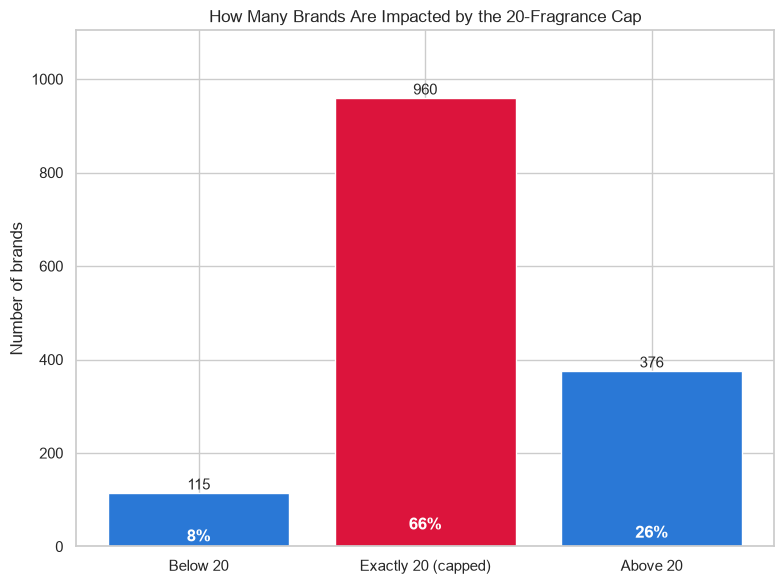

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid", palette="deep")

df = pd.read_parquet("../data/cleaned_data.parquet")
brand_counts = df["Brand"].value_counts()

groups = pd.Series({
    "Below 20": (brand_counts < 20).sum(),
    "Exactly 20 (capped)": (brand_counts == 20).sum(),
    "Above 20": (brand_counts > 20).sum(),
})
pct = groups / groups.sum() * 100

colors = ["#2a78d6", "crimson", "#2a78d6"]
fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.bar(groups.index, groups.values, color=colors)
for bar, count, p in zip(bars, groups.values, pct.values):
    ax.annotate(f"{count}", (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                ha="center", va="bottom", fontsize=11)
    ax.annotate(f"{p:.0f}%", (bar.get_x() + bar.get_width() / 2, bar.get_height() * 0.03),
                ha="center", va="bottom", fontsize=12, color="white", fontweight="bold")
ax.set(ylabel="Number of brands", title="How Many Brands Are Impacted by the 20-Fragrance Cap")
ax.margins(y=0.15)
plt.tight_layout()
plt.show()



**How many brands this touches**

66% of all brands (960 of 1,451) sit at the pagination cap of 20 fragrances. Only 8% (115 brands) genuinely have fewer than 20, and just 26% (376 brands) show up as clearly uncapped. In other words, for roughly two out of every three brands in this dataset, the fragrance count on record says nothing about their real catalog size. It's just wherever parfumo's first listing page happened to stop. That order is probably the site's own default catalog order.